<a href="https://colab.research.google.com/github/Abhay-07082005/food-freshness-app/blob/main/freshsense_AI_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow matplotlib pandas scikit-learn -q


In [ ]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

DATASET_PATH = "/content/dataset/Fruits_Vegetables_Dataset(12000)/Fruits"
print("Dataset extracted to:", DATASET_PATH)

Dataset extracted to: /content/dataset/Fruits_Vegetables_Dataset(12000)/Fruits


In [ ]:

QUALITY_BASE_SCORE = {
    "fresh": 95,
    "mixed": 65,
    "medium": 65,
    "good": 65,
    "rotten": 20,
    "bad": 20,
}
MAX_SHELF_LIFE_DAYS = {
    "apple": 30,
    "banana": 7,
    "guava": 5,
    "lemon": 30,
    "orange": 21,
    "pomegranate": 60,
}

JITTER_STD = 6.0

def parse_folder_name(folder_name):
    """Extract (fruit, quality) from a folder name like 'freshapple' or 'rottenbanana'."""
    name = folder_name.lower()
    quality = "mixed"
    for q in ["fresh", "rotten", "bad", "mixed", "medium", "good"]:
        if q in name:
            quality = q
            name = name.replace(q, "")
            break
    fruit = name.strip("_- ")
    for known_fruit in MAX_SHELF_LIFE_DAYS:
        if known_fruit in name:
            fruit = known_fruit
            break
    return fruit, quality

def compute_labels(fruit, quality, rng):
    base = QUALITY_BASE_SCORE.get(quality, 65)
    freshness_pct = float(np.clip(base + rng.normal(0, JITTER_STD), 0, 100))
    max_days = MAX_SHELF_LIFE_DAYS.get(fruit, 14)
    days_left = round(max_days * (freshness_pct / 100.0))
    return freshness_pct, days_left

In [ ]:
rng = np.random.default_rng(SEED)

records = []
for folder_name in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue
    fruit, quality = parse_folder_name(folder_name)
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        freshness_pct, days_left = compute_labels(fruit, quality, rng)
        records.append({
            "filepath": os.path.join(folder_path, fname),
            "fruit": fruit,
            "quality": quality,
            "freshness_pct": freshness_pct,
            "days_left": days_left,
        })

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 5988


,filepath,fruit,quality,freshness_pct,days_left
0,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,89.065272,27
1,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,92.793280,28
2,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,100.000000,30
3,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,96.163847,29
4,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,100.000000,30


In [ ]:
class_names = sorted(df["fruit"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}
df["fruit_idx"] = df["fruit"].map(class_to_index)

print("Classes:", class_names)

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["fruit_idx"]
)
print("Train size:", len(train_df), "| Val size:", len(val_df))


Classes: ['apple', 'banana', 'mango', 'orange', 'strawberry']
Train size: 4790 | Val size: 1198


In [ ]:
import os

print(os.listdir("/content/dataset/Fruits_Vegetables_Dataset(12000)"))

['Vegetables', 'Fruits']


In [ ]:
def load_image(filepath):
  img = tf.io.read_file(filepath)

  img = tf.io.decode_image(
      img,
      channels=3,
      expand_animations=False
  )
  img.set_shape([None, None, 3])
  img = tf.image.resize(img, IMG_SIZE)
  img = preprocess_input(img)

  return img

def make_dataset(dataframe, training=False):
    filepaths = dataframe["filepath"].values
    fruit_idx = dataframe["fruit_idx"].values.astype("int32")
    freshness = dataframe["freshness_pct"].values.astype("float32")
    days = dataframe["days_left"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((filepaths, fruit_idx, freshness, days))

    def _map_fn(fp, f_idx, fresh, dl):
        img = load_image(fp)
        labels = {
            "fruit_class": f_idx,
            "freshness_pct": fresh,
            "days_left": dl,
        }
        return img, labels

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)


In [ ]:
num_classes = len(class_names)

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze pretrained backbone initially

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
h = layers.Dense(128, activation="relu")(x)

fruit_class_out = layers.Dense(num_classes, activation="softmax", name="fruit_class")(h)

freshness_raw = layers.Dense(1, activation="sigmoid")(h)
freshness_pct_out = layers.Lambda(lambda t: t * 100.0, name="freshness_pct")(freshness_raw)

days_left_out = layers.Dense(1, activation="relu", name="days_left")(h)

model = Model(inputs=inputs, outputs=[fruit_class_out, freshness_pct_out, days_left_out])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fruit_class (Dense) │ (None, 5)         │        645 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ freshness_pct       │ (None, 1)         │          0 │ dense_1[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ days_left (Dense)   │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss={
        "fruit_class": "sparse_categorical_crossentropy",
        "freshness_pct": "mse",
        "days_left": "mse",
    },
    loss_weights={
        "fruit_class": 1.0,
        "freshness_pct": 0.01,
        "days_left": 0.01,
    },
    metrics={
        "fruit_class": "accuracy",
        "freshness_pct": "mae",
        "days_left": "mae",
    },
)


In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - days_left_loss: 56.9748 - days_left_mae: 5.3756 - freshness_pct_loss: 356.8572 - freshness_pct_mae: 13.1678 - fruit_class_accuracy: 0.8296 - fruit_class_loss: 0.4691 - loss: 4.6132 - val_days_left_loss: 22.4837 - val_days_left_mae: 3.3731 - val_freshness_pct_loss: 166.0608 - val_freshness_pct_mae: 8.9195 - val_fruit_class_accuracy: 0.9683 - val_fruit_class_loss: 0.1309 - val_loss: 2.0353
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - days_left_loss: 19.1672 - days_left_mae: 3.1155 - freshness_pct_loss: 180.3666 - freshness_pct_mae: 9.5167 - fruit_class_accuracy: 0.9574 - fruit_class_loss: 0.1392 - loss: 2.1362 - val_days_left_loss: 14.7268 - val_days_left_mae: 2.6562 - val_freshness_pct_loss: 144.8675 - val_freshness_pct_mae: 8.1984 - val_fruit_class_accuracy: 0.9758 - val_fruit_class_loss: 0.0863 - val_loss: 1.6898
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - days_left_loss: 14.2301 - days_left_mae: 2.6588 - fres

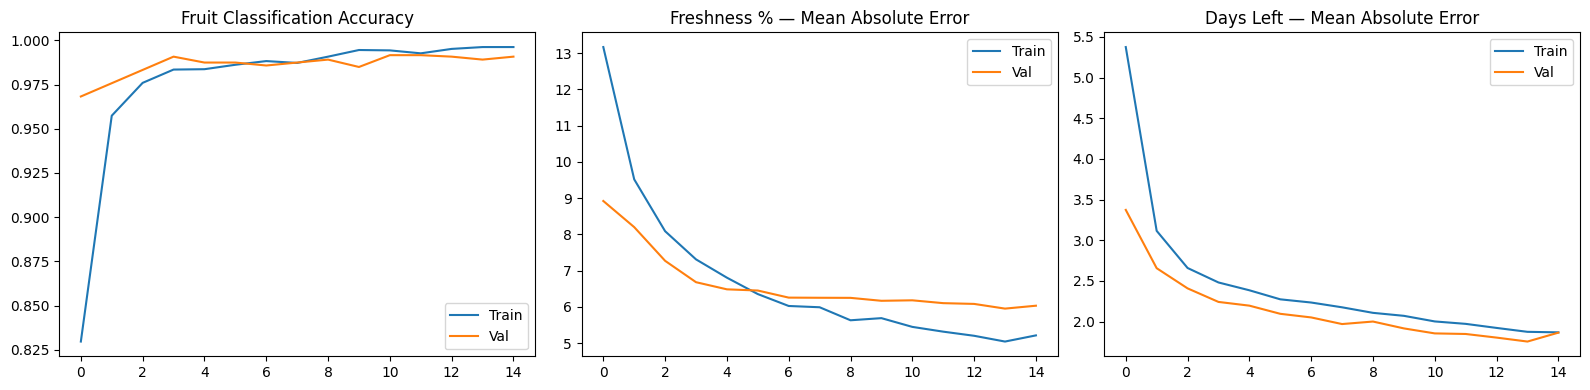

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["fruit_class_accuracy"], label="Train")
axes[0].plot(history.history["val_fruit_class_accuracy"], label="Val")
axes[0].set_title("Fruit Classification Accuracy")
axes[0].legend()

axes[1].plot(history.history["freshness_pct_mae"], label="Train")
axes[1].plot(history.history["val_freshness_pct_mae"], label="Val")
axes[1].set_title("Freshness % — Mean Absolute Error")
axes[1].legend()

axes[2].plot(history.history["days_left_mae"], label="Train")
axes[2].plot(history.history["val_days_left_mae"], label="Val")
axes[2].set_title("Days Left — Mean Absolute Error")
axes[2].legend()

plt.tight_layout()
plt.show()


In [20]:
model.save("food_freshness_model_v2.keras")
print("Model saved successfully!")


Model saved successfully!


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Collect true labels and predictions across the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    fruit_probs = preds[0]  # first output head = fruit_class
    y_pred.extend(np.argmax(fruit_probs, axis=1))
    y_true.extend(labels["fruit_class"].numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       apple       0.98      0.99      0.98       239
      banana       0.99      1.00      0.99       239
       mango       1.00      1.00      1.00       240
      orange       1.00      0.97      0.99       240
  strawberry       1.00      1.00      1.00       240

    accuracy                           0.99      1198
   macro avg       0.99      0.99      0.99      1198
weighted avg       0.99      0.99      0.99      1198



In [22]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

for cls in class_names:
    precision_pct = report[cls]["precision"] * 100
    recall_pct = report[cls]["recall"] * 100
    f1_pct = report[cls]["f1-score"] * 100
    print(f"{cls}: Precision={precision_pct:.2f}%  Recall={recall_pct:.2f}%  F1={f1_pct:.2f}%")

apple: Precision=97.93%  Recall=98.74%  F1=98.33%
banana: Precision=98.76%  Recall=99.58%  F1=99.17%
mango: Precision=99.58%  Recall=99.58%  F1=99.58%
orange: Precision=99.57%  Recall=97.50%  F1=98.53%
strawberry: Precision=99.59%  Recall=100.00%  F1=99.79%


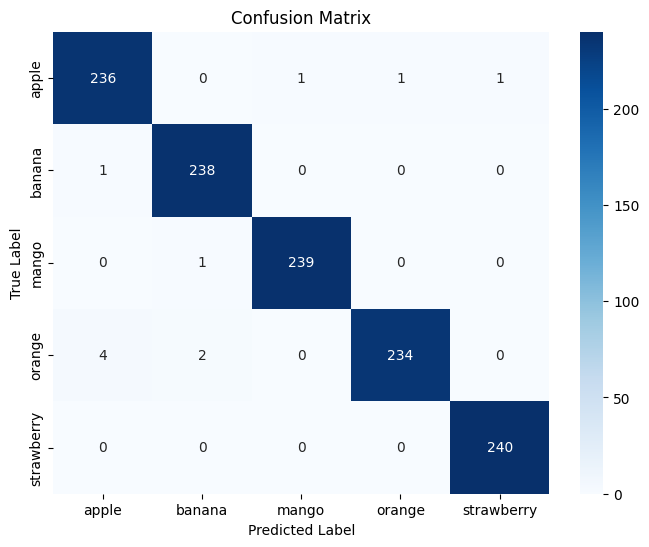

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

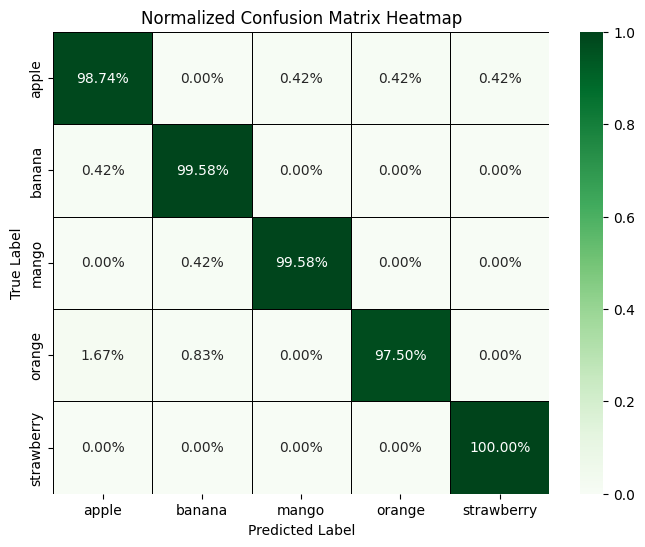

In [24]:
import numpy as np

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    linewidths=0.5,
    linecolor="black",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [25]:
from tensorflow.keras.utils import load_img, img_to_array

def predict(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    class_probs, freshness_pct, days_left = model.predict(img)

    class_probs = class_probs[0]
    freshness_pct = float(freshness_pct[0][0])
    days_left = float(days_left[0][0])

    idx = int(np.argmax(class_probs))
    fruit_confidence = float(class_probs[idx]) * 100

    print("Fruit:", class_names[idx], f"({fruit_confidence:.2f}% confidence)")
    print(f"Freshness: {freshness_pct:.1f}%")
    print(f"Estimated days left: {days_left:.1f}")

    if freshness_pct >= 80:
        print("Status: GOOD (Fresh)")
    elif freshness_pct >= 50:
        print("Status: MODERATE")
    elif freshness_pct >= 25:
        print("Status: NOT GOOD")
    else:
        print("Status: ROTTEN")

    return {
        "fruit": class_names[idx],
        "fruit_confidence": fruit_confidence,
        "freshness_pct": freshness_pct,
        "days_left": days_left,
    }


In [26]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict(img_path)


Saving freshPepper (320).jpg to freshPepper (320).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Fruit: apple (99.63% confidence)
Freshness: 91.8%
Estimated days left: 15.7
Status: GOOD (Fresh)


{'fruit': 'apple',
 'fruit_confidence': 99.63164329528809,
 'freshness_pct': 91.7791748046875,
 'days_left': 15.716794967651367}